**Module**: Data 9910 – Working with Data

**Lecturer**: Lucas Rizzo

**Class Group**: TU059/060/256

**Worth**: 20%

**Due Time**: Before next class on Week 6.

**Programming Language**: The test can be done in both `R` or `Python`. You can change the kernel language going in *Kernel > Change Kernel*


**Student Details**

- student name = eamonn kelly
- student number = D24127620

### Submission

Please submit this notebook and additional files (if any) in a zip file. ***Submissions without a report won't be accepted.***

# Problem description

A telecommunications company is starting a data project to improve their customer analytics capabilities. During informal interviews with the stakeholders, the following were suggested as possible features for the system:

- identify trends by certain types of customers
- identify trends by certain types of calls
- identify relevant statistical information of overall calls performed by customers


# Dataset

The company has provided you with an sql dump in two files (`db.ddl` and `data.sql`) to replicate their PostgreSQL database. However, they are not very organised and did not provide a documentation alongside it. Hence, you will be required to recreate it and do some investigation to understand their data. Note that a ddl file also containts sql commands, but only those that describes the portion of SQL that creates, alters, and deletes database objects

### Create a new local database

Using pgAdmin create a new server to run the sql files.

![Screenshot of pgAdmin 4 to create a new connection](new_connection.jpg)

You can use the parameters below to create the databse. If you use different ones you will need to remember them to connect to the database.

`user = 'postgres'`

`password = 'admin'`

`host = 'localhost'`

`port = 5432`

`database = 'telecommunications'`


### Import the data

Using the query tool open the `db.ddl` file and run the commands to create the necessary tables. After that, open the `data.sql` to run the insert commands and add all the data to the database (this can take around 20 seconds to run).

![Screenshot of pgAdmin 4 to open a SQL file in the query tool](query_tool.jpg)

### QUESTION 1

Using your preferred language (R or Python) create a connection object to the companies database. (1 mark)

In [3]:
# import required packages
import sqlalchemy as db
from sqlalchemy import text
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import numpy as np



In [4]:
# create a connection to the telecommunications database
user = 'postgres'
password = 'password0134!'
host = 'localhost'
port = 5432
database = 'telecommunications'

engine = db.create_engine('postgresql+psycopg2://{0}:{1}@{2}:{3}/{4}'.format(user,
                                                                    password,
                                                                    host,
                                                                    port,
                                                                    database))
conn = engine.connect()


### QUESTION 2

Extract the ERD from the database (this can be done via PgAdmin or via sqlalchemy_schemadisplay). Write a general description of the database structure (2 marks)


Below is an overview of the **telecommunications** database and  its Entity Relationship Diagram (ERD).

### Tables
There are 4 tables present in the database
- *call_rates*
    - Primary Key = *callrate* - this is a unique identifier
    - Foreign Key = None - no constraints on tables values
    - Attributes and datatype =
        - *callrate* = int
        - *isinternatioal* = VARCHAR(5)
        - *isroaming* = VARCHAR(5)
        - *costperminute* = numeric(4,2) precision and scale values (00.00) 
- *calls*
    - Primary Key = *connectionid* - this is a unique identifier
    - Foreign Keys = *call_rates.callrate* + *customers.phonenumber*
    - attributes =
        - *phonenumber* = VARCHAR(13)
        - *calltime* = VARCHAR(16)
        - *duration* = numeric(13,9) precision and scale values (0000.000000000) 
        - *connectionid* = VARCHAR(36)
        - *callrate* = int
- *customers*
    - Primary Key = *phonenumber* - this is a unique identifier
    - Foreign Key = None - no constraints on tables values
    - attributes =
        - *phonenumber* = VARCHAR(13)
        - *contractstartdate* = date
        - *dob* = date
- *customer_service*
    - Primary Key = *connectionid* - this is a unique identifier
    - Foreign Key = calls.connectionid - 
    - attributes =
        - *connectionid* = VARCHAR(36)

### Relationships
- The *calls* table is a bridging entity between the customers and call_rates tables.
    - *callrate* could have many *calls* associated with it but a *call* can have only one *callrate*
    - *customers* could have many *calls* but a *call* can only have one *customer*
- The *customer_service* table has a one to one relationship with the *calls* table
    - a *customer_service* entry can only have one *call* and *call* can only have one *customer_service* id

### ERD diagram
![telecommunication database erd diagram](./tcomm-erd-2.png)

### Shape and Structure
We will perform some high level analysis on the data to get a feel for the structure and type of daa we have. We will place the db tables into a dictionary with the table names as the keys, this will allow me to more easily loop through them and utilise some of the built in pandas functionality supporting data analysis. Later, for reporting , we will place the sql tables and queried sql data in a pandas dataframe for  final analysis and visualization.

In [5]:
# place the db tables into a pandas dataframe and place that dataframe into a dictionary with the table names as the keys
# this will allow me to more easily loop through them and utilise some of the built in pandas functionaility supporting data analysis
# 

# we wil create the MetaData object first as required by SQLAlchemy

metadata_obj = db.MetaData() # import and initialise a metadata obj
metadata_obj.reflect(bind=engine) # reflect

db_table_names = ["customers", "calls", "customer_service", "call_rates"]

# create a dictionary to place the tables into in python
tbls_dict ={}

# loop through the tables using the selct query to get all the table rows and columns into a dictionary, some references used from here
# https://stackoverflow.com/questions/24959589/get-table-columns-from-sqlalchemy-table-model
for table_name in db_table_names:
        table = db.Table(table_name, metadata_obj, autoload=True, autoload_with=engine) # create a sqlalchemy table object we cna manipulate
        stmt = db.select(table)       # select statement in SQLALchemy
        result = conn.execute(stmt).fetchall() # execute the query in the connection and store the return in results using fetchall to return all rows
        columns = table.columns.keys() # get columns names which will sue in dictionary
        # put results into dictionary created earlier, specifies the table name as the key so cna access by table name
        tbls_dict[table_name] = pd.DataFrame(result, columns=columns)
        
# get the shape of all four tables i.e. num rows and columns 
print('----table shape--------------------')

for table_name, df in tbls_dict.items():
        print(f"{table_name} : {df.shape}")

        
for table_name, df in tbls_dict.items():
        print((f"------------------------ table_name   = {table_name})  -------------------------------"))
        missing_cnt = (df=='?').sum()
        print('\"  <<<    ?   >>>   \" values present =  \n', missing_cnt)
        print('------')
        unknown_cnt = (df=='unknown').sum()
        print('\"   <<< unknown >>>   \" values present =  \n', unknown_cnt)
        print('------')
        na_cnt = df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
        print('   <<<  NA  >>>    values present = \n', na_cnt)
        print('------')
        none_cnt = df.isin(['None', 'none']).sum()
        print('    none    values present = \n', none_cnt)
        print('------')
        dup_rows = (df.duplicated().sum())
        print('   <<< duplicate rows  >>>  =  \n', dup_rows)





----table shape--------------------
customers : (4999, 3)
calls : (161584, 5)
customer_service : (16189, 1)
call_rates : (4, 4)
------------------------ table_name   = customers)  -------------------------------
"  <<<    ?   >>>   " values present =  
 phonenumber          0
contractstartdate    0
dob                  0
dtype: int64
------
"   <<< unknown >>>   " values present =  
 phonenumber          0
contractstartdate    0
dob                  0
dtype: int64
------
   <<<  NA  >>>    values present = 
 phonenumber          0
contractstartdate    0
dob                  0
dtype: int64
------
    none    values present = 
 phonenumber          0
contractstartdate    0
dob                  0
dtype: int64
------
   <<< duplicate rows  >>>  =  
 0
------------------------ table_name   = calls)  -------------------------------
"  <<<    ?   >>>   " values present =  
 phonenumber     0
calltime        0
duration        0
connectionid    0
callrate        0
dtype: int64
------
"   <<< un

We can see from the queries run in the previous code cell, we have 4 tables.
- max number of rows we have is '161584'
- amx number of columns we have is '5'

The tables are relatively large, apart from the *call_rates* table. 

Also, there are no 'NA' ( or variations of NA), 'unknown', 'NULL' or '?' values present in the tables. There are also no duplicate rows, which is as we would expect with the database integrity processes and primary key usage. Overall, the data looks reasonably clean and well structured. We have also seen earlier, by manually looking and querying the tables directly in PostGRESql, the datatypes that are present, listed earlier.

# Customer information

Query the database to extract the following information:

a) The overall number of customers (1 mark)

In [6]:
# We will establish the number of customers by calculating the number of rows in the customer table
# because we earlier verified there are no duolicates entries in any of the tables, including the customer table,  
# as such this is a valid test as each row corresponds to a unique customer.
# # establish connection
result = conn.execute(text("SELECT COUNT(*) FROM customers"))

# hav to use fetchone, as fetch returns nothing, fetch all give two elements, and fetch many returns full tuple, the second one being empty
# fetchone is returning first column in the next row of the resutl values returned'
num_cust=result.fetchone()[0]
print(f' Total number of customers  = {num_cust}')


 Total number of customers  = 4999


b) The number of customers by year of DOB in descending order (2 marks)

In [7]:
# we'll put a sql query straight into the db and get the rsult
# stmt = db.select(
    
stmt = ("SELECT EXTRACT(YEAR FROM dob) AS birth_year, COUNT(*) AS num_customers FROM customers GROUP BY birth_year ORDER BY birth_year DESC")

result = conn.execute(text(stmt)).fetchall()

# put it into a dataframe to more easily format it for viewing
df=pd.DataFrame(result, columns=['year_born', 'num_custs'])
print(df)
# will cross valdiate the answer bty checkgin the total number in the data = the tital num  of customers we calcualted earier
# thsi is just an extra layer of cross validation that our answer is correct
print("total customers validation from results ", df['num_custs'].sum()) # to check if total number  = 4999

   year_born  num_custs
0       2000          1
1       1999         97
2       1998         89
3       1997        115
4       1996         87
5       1995        105
6       1994        108
7       1993         98
8       1992         94
9       1991         99
10      1990         92
11      1989         96
12      1988         96
13      1987        105
14      1986        107
15      1985        100
16      1984         80
17      1983         99
18      1982         97
19      1981         91
20      1980        104
21      1979         70
22      1978        108
23      1977        101
24      1976        112
25      1975        111
26      1974        102
27      1973        105
28      1972         95
29      1971         97
30      1970        105
31      1969        105
32      1968         76
33      1967         93
34      1966         96
35      1965         98
36      1964        108
37      1963         83
38      1962        105
39      1961        105
40      1960    

c) Analyse the query below and describe what is the result given by it. (1 mark)

In [8]:
# Python (uncomment if you are using Python)
result = conn.execute(text("SELECT c.phonenumber, SUM(cr.costperminute * c.duration) AS total_amount_spent " + 
                      "FROM public.calls c INNER JOIN public.call_rates cr ON c.callrate = cr.callrate "
                      "WHERE c.connectionid NOT IN ( SELECT DISTINCT connectionid FROM public.customer_service) " +
                      "GROUP BY c.phonenumber ORDER BY c.phonenumber;"))
for row in result:
    print(row)

# R (uncomment if you are using R)
# query <- "SELECT c.phonenumber, SUM(cr.costperminute * c.duration) AS total_amount_spent"
# query <- paste(query, "FROM public.calls c INNER JOIN public.call_rates cr ON c.callrate = cr.callrate")
# query <- paste(query, "WHERE c.connectionid NOT IN ( SELECT DISTINCT connectionid FROM public.customer_service)")
# query <- paste(query, "GROUP BY c.phonenumber ORDER BY c.phonenumber;")

# result <- dbGetQuery(con, query)

# result

('01 000 9436', Decimal('3201.22279225500'))
('01 001 6896', Decimal('11069.16794494900'))
('01 001 9955', Decimal('3143.07759377700'))
('01 002 1488', Decimal('7667.06401183800'))
('01 002 1807', Decimal('1037.42097668100'))
('01 002 3138', Decimal('10969.08258640800'))
('01 002 7003', Decimal('25476.58783680990'))
('01 003 5862', Decimal('2178.43534643600'))
('01 004 1518', Decimal('1583.04664798870'))
('01 004 3369', Decimal('1893.67951344500'))
('01 004 6123', Decimal('3919.39081954100'))
('01 005 3059', Decimal('6618.55011914400'))
('01 005 7353', Decimal('2169.99057156000'))
('01 005 8909', Decimal('16340.42254020600'))
('01 005 9012', Decimal('13579.88341802100'))
('01 006 5619', Decimal('9908.71578357400'))
('01 006 8032', Decimal('6544.87565328800'))
('01 007 0548', Decimal('10625.15229737000'))
('01 007 3126', Decimal('16346.97708737820'))
('01 008 0438', Decimal('11732.57507735700'))
('01 008 1378', Decimal('16202.03157874900'))
('01 008 2702', Decimal('2093.73442266500'))
(

##'' C) Answer
The query is getting how much each phone number  was charged on calls, excluding any calls to customer service.
- it excludes any calls that were made to customer service.
- cost per min * duration = total amount spent
- performs a join on *calls.callrate* and *call_rates.callrate*
- creates buckets for 'phonenumbers' and GROUP by phone numbers to group by phonenumebrs
- ORDER by - by default this is ascending, we do not specify in the query, so it is ascending order.

**NOTE:** The assumption that a customer could have more than one phone comes into play in interpreting this query however. This query calculates how mch was charged to each phone, and not how much was charged to each customer, as a customer could have more than one phone. The query does not take that into consideration. To calculate the spend per customer we would need to modify the query.


d) There is a logical error on the result of the above query. As a telecommunications specialist, you have observed that the `total_amount_spent` returned is too high for the usual expected values in this industry. Please fix the query so that values falls in a reasonable range. (1 mark)

### d) Answer

1)  calculating the costs
    - callrate = cost per minute as per *call_rate* table (header gives unit - it is euros i.e. 0.52 euro per min)
    - duration (13, 9) = does not specify a unit (assume it is seconds i.e. 828.798418100 seconds)
    - must modify duration calculation  > to be (duration / 60) to get duration of calls in minutes, rather than seconds.

 Use of the term 'public' refers to the schema, so public.calls refers to calls table in the public schema in the telecommunications database, which exists and is fine. we could remove that and get the same result if we wished, but if there were multiple schemas we woudl need to specify.

- Updated query listed below and run.


In [9]:
# corrected code listed below - 
# (duration / 60) has been added to convert call duration from sec to min units
result = conn.execute(text("SELECT c.phonenumber, SUM(cr.costperminute * c.duration/60) AS total_amount_spent " + 
                      "FROM public.calls c INNER JOIN public.call_rates cr ON c.callrate = cr.callrate "
                      "WHERE c.connectionid NOT IN ( SELECT DISTINCT connectionid FROM public.customer_service) " +
                      "GROUP BY c.phonenumber ORDER BY c.phonenumber;"))
for row in result:
    print(row)

('01 000 9436', Decimal('53.35371320425000010000'))
('01 001 6896', Decimal('184.48613241581666670000'))
('01 001 9955', Decimal('52.38462656294999990000'))
('01 002 1488', Decimal('127.78440019729999993333'))
('01 002 1807', Decimal('17.29034961135000000000'))
('01 002 3138', Decimal('182.81804310679999986667'))
('01 002 7003', Decimal('424.60979728016499986667'))
('01 003 5862', Decimal('36.30725577393333346667'))
('01 004 1518', Decimal('26.38411079981166666667'))
('01 004 3369', Decimal('31.56132522408333330000'))
('01 004 6123', Decimal('65.32318032568333330000'))
('01 005 3059', Decimal('110.30916865239999993333'))
('01 005 7353', Decimal('36.16650952599999993333'))
('01 005 8909', Decimal('272.34037567009999980000'))
('01 005 9012', Decimal('226.33139030034999980000'))
('01 006 5619', Decimal('165.14526305956666640000'))
('01 006 8032', Decimal('109.08126088813333340000'))
('01 007 0548', Decimal('177.08587162283333343333'))
('01 007 3126', Decimal('272.44961812296999983334'))
(

e) Given the correct query for the `total_amount_spent` spent, identify the min, max and average revenue gererate by overall phone numbers (1 mark)

In [10]:
# we have the query above, so will just use that as our query and get the min, max and avg off the cost column in that output 
# so substitute the query above for out FROM value
conn.rollback()
result = conn.execute(text("Select MIN(total_amount_spent ), MAX(total_amount_spent ), AVG(total_amount_spent) " 
                        "FROM (" 
                        "SELECT c.phonenumber, SUM(cr.costperminute * c.duration/60) AS total_amount_spent " 
                        "FROM public.calls c INNER JOIN public.call_rates cr ON c.callrate = cr.callrate "
                        "WHERE c.connectionid NOT IN ( SELECT DISTINCT connectionid FROM public.customer_service) "
                        "GROUP BY c.phonenumber"
                        ")"
))
# assign the query result to a variable, a tuple which we will then access
minmaxavg = result.fetchone()

# assign the values from the result tuple object which we got from our sql query to the database
# we roudn up to 2 decimal places aswell.
minval=round(minmaxavg[0], 2)
maxval=round(minmaxavg[1], 2)
avgval=round(minmaxavg[2], 2)
    
# print otu the result and some explanatory text to go with it.
print(f"min revenue per phone number: {minval} euro")
print(f"max revenue per phone number: {maxval} euro")
print(f"avg revenue per phone number: {avgval} euro")

min revenue per phone number: 0.14 euro
max revenue per phone number: 483.59 euro
avg revenue per phone number: 125.14 euro


# Calls information

### Question 4

Query the database to extract the following information:

a) The average call duration in minutes per phone number, excluding those made to the customer service (2 marks)

In [11]:
conn.rollback()
result = conn.execute(text("SELECT c.phonenumber, AVG(c.duration/60) AS avg_call_duration_mins " 
                        "FROM public.calls c INNER JOIN public.call_rates cr ON c.callrate = cr.callrate "
                        "WHERE c.connectionid NOT IN ( SELECT DISTINCT connectionid FROM public.customer_service) "
                        "GROUP BY c.phonenumber "
                        "ORDER BY c.phonenumber;"
                        #")"
)
)

# get the value from the tuple result returned byt the sql query
avg_call_dur_result = result.fetchall()

# loop through the values, assigning a value to the first and second values in the tuple result
# this just allow us call them in print satement with mroe descriptive details
for row in avg_call_dur_result:
    phonenumber = row[0]
    avg_duration = row[1]
    print(f" phone number = {phonenumber}  --  average call duration in mins : {round(avg_duration, 2)}")

 phone number = 01 000 9436  --  average call duration in mins : 12.26
 phone number = 01 001 6896  --  average call duration in mins : 17.20
 phone number = 01 001 9955  --  average call duration in mins : 13.17
 phone number = 01 002 1488  --  average call duration in mins : 15.98
 phone number = 01 002 1807  --  average call duration in mins : 9.34
 phone number = 01 002 3138  --  average call duration in mins : 16.66
 phone number = 01 002 7003  --  average call duration in mins : 19.11
 phone number = 01 003 5862  --  average call duration in mins : 16.18
 phone number = 01 004 1518  --  average call duration in mins : 11.59
 phone number = 01 004 3369  --  average call duration in mins : 17.85
 phone number = 01 004 6123  --  average call duration in mins : 16.44
 phone number = 01 005 3059  --  average call duration in mins : 12.40
 phone number = 01 005 7353  --  average call duration in mins : 11.89
 phone number = 01 005 8909  --  average call duration in mins : 15.85
 phone 

b) The number of calls made to customer support by phone number (2 marks)

In [12]:
conn.rollback()
result = conn.execute(text("SELECT calls.phonenumber, COUNT(*) as num_alls_made_to_cust_serv " 
                        "FROM calls "
                        "INNER JOIN customer_service "
                        "ON calls.connectionid = customer_service.connectionid "
                        "GROUP BY calls.phonenumber "
                        "ORDER BY calls.phonenumber;"
                        #")"
)
)

# get the value from the tuple result returned byt the sql query
num_calls_to_cs = result.fetchall()

# loop through the values, assigning a value to the first and second values in the tuple result
# this just allow us call them in print satement with mroe descriptive details
for row in num_calls_to_cs:
    phonenumber = row[0]
    num_calls_to_cust_services= row[1]
    print(f" phone number = {phonenumber}  --  number of calls to customer service : {num_calls_to_cust_services}")

 phone number = 01 000 9436  --  number of calls to customer service : 1
 phone number = 01 001 6896  --  number of calls to customer service : 5
 phone number = 01 001 9955  --  number of calls to customer service : 4
 phone number = 01 002 1488  --  number of calls to customer service : 3
 phone number = 01 002 3138  --  number of calls to customer service : 6
 phone number = 01 002 7003  --  number of calls to customer service : 3
 phone number = 01 003 5862  --  number of calls to customer service : 2
 phone number = 01 004 1518  --  number of calls to customer service : 2
 phone number = 01 004 3369  --  number of calls to customer service : 1
 phone number = 01 004 6123  --  number of calls to customer service : 3
 phone number = 01 005 3059  --  number of calls to customer service : 2
 phone number = 01 005 7353  --  number of calls to customer service : 1
 phone number = 01 005 8909  --  number of calls to customer service : 9
 phone number = 01 005 9012  --  number of calls to

c) The number of calls made by call rate (2 marks)

In [13]:
conn.rollback()
result = conn.execute(text("SELECT calls.callrate, COUNT(*) as num_calls_per_rate " 
                        "FROM calls "
                        "GROUP BY calls.callrate "
                        "ORDER BY calls.callrate;"
                        #")"
)
)

# get the value from the tuple result returned byt the sql query
num_calls_per_callrate = result.fetchall()

# we have 4 rates in our output data i a list of tuples
# given its 4 rates we'll put it into a data fram instead of looping through the list and pritning to mak it a bit easier to read

# we'lla ssign the tuple object to a pandas df and specify the coumn names, then pritn it out to view it
num_call_per_rate_df = pd.DataFrame(num_calls_per_callrate, columns=['callrate', 'num_of_calls'] )
print(num_call_per_rate_df)


   callrate  num_of_calls
0         1         40467
1         2         40326
2         3         40632
3         4         40159


# Report

Describe your findings in a short report, summarizing the information you have collected from previous questions and giving some interpretation of results. You might for example generate a table with results, and give some interpretation in a few sentences. You can also imagine you are an analyst interested in reading this report and collecting the most important information extracted from the data. (5 marks)

In [14]:
# Calculate total revenue per call rate - to see which are most profitable
# we multiple cost per min by call duration converted to mins and SUm that for each rate
# exclude customer servcie calls as w did earlier
conn.rollback()
result = conn.execute(text("SELECT call_rates.callrate, SUM(calls.duration/60 * call_rates.costperminute) AS total_revenue "
                           "FROM calls "
                           "JOIN call_rates "
                           "ON calls.callrate = call_rates.callrate "
                           "WHERE calls.connectionid NOT IN (SELECT connectionid FROM customer_service) "
                           "GROUP BY call_rates.callrate "
                           "ORDER BY total_revenue DESC "
                        #")"
)
)

rev_per_cr = result.fetchall()


rev_per_cr_df = pd.DataFrame(rev_per_cr, columns=['callrate', 'total revenue euro'] )
# reveue is a string object - need to convert to numeric and also round to 2 decomal places
rev_per_cr_df['total revenue euro'] = pd.to_numeric(rev_per_cr_df['total revenue euro'])
rev_per_cr_df['total revenue euro'] = rev_per_cr_df['total revenue euro'].round(2)

# display table for total revenue per call rate
print(rev_per_cr_df)


   callrate  total revenue euro
0         1           312593.02
1         2           143787.12
2         3           143047.63
3         4            16238.57


In [15]:
# have two dataframes created earlier based around revenue, calls and rate i.e. 'num_call_per_rate_df' and 'rev_per_cr_df'
# Also have a dictinoary with all 4 tables already in it >> 'tbls_dict' > again creted earlier, 
# will merge these three dataframes to give one full table and can perform some analysis on that data then

# put the dictionary into dataframes then print out all three dataframes
call_rates_df = tbls_dict['call_rates']
# commented the 3 dataframes otu just to reduce noise int he output but yuo can uncomment and lok at the dataframes if you wish
# print(call_rates_df)
# print(num_call_per_rate_df)
# print(rev_per_cr_df)

#now merge the 3 dataframes into one
# merge num calls df with total revenue df
num_calls_rev_rate_df = pd.merge(num_call_per_rate_df, rev_per_cr_df, on='callrate')
# merge with call rates tables
full_rates_df = pd.merge(num_calls_rev_rate_df, call_rates_df, on='callrate')
full_rates_df['costperminute'] = pd.to_numeric(full_rates_df['costperminute'])
print("This is our merged dataframe with dataframes, cal_rates sq table and sql table data, merged into one")
print("------------------------------------------------------------------------------------")
print(full_rates_df)
# commented tuo to reduce noise in output display btu again can uncomment and view if you wish or need
# print(full_rates_df.columns)
# print(full_rates_df.dtypes)

This is our merged dataframe with dataframes, cal_rates sq table and sql table data, merged into one
------------------------------------------------------------------------------------
   callrate  num_of_calls  total revenue euro isinternational isroaming  \
0         1         40467           312593.02            TRUE      TRUE   
1         2         40326           143787.12            TRUE     FALSE   
2         3         40632           143047.63           FALSE      TRUE   
3         4         40159            16238.57           FALSE     FALSE   

   costperminute  
0           0.57  
1           0.26  
2           0.26  
3           0.03  


In [16]:
# get summary statistics from the data mean, sd, median etc
summary_stats = full_rates_df.describe()
print(summary_stats)

       callrate  num_of_calls  total revenue euro  costperminute
count  4.000000       4.00000            4.000000        4.00000
mean   2.500000   40396.00000       153916.585000        0.28000
std    1.290994     201.49938       121592.471097        0.22166
min    1.000000   40159.00000        16238.570000        0.03000
25%    1.750000   40284.25000       111345.365000        0.20250
50%    2.500000   40396.50000       143417.375000        0.26000
75%    3.250000   40508.25000       185988.595000        0.33750
max    4.000000   40632.00000       312593.020000        0.57000


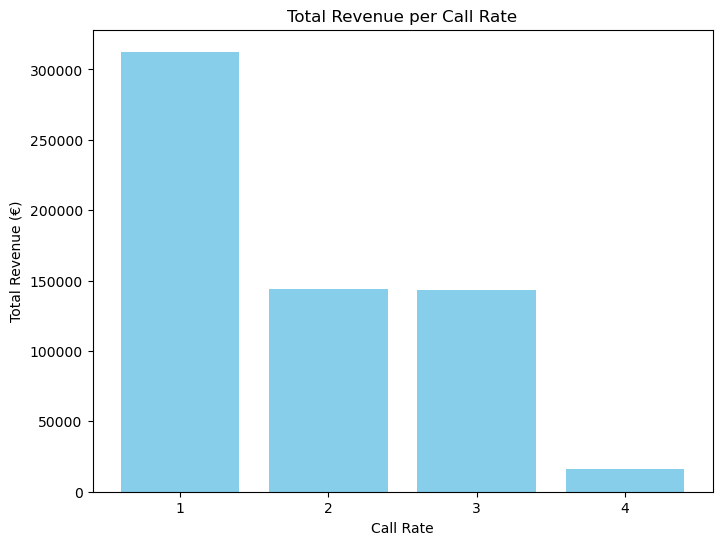

In [17]:
# Plot of revenue vs call rate - what rate drives the most revnenue
# 
plt.figure(figsize=(8,6))
plt.bar(full_rates_df['callrate'].astype(str), full_rates_df['total revenue euro'], color='skyblue')
plt.xlabel('Call Rate')
plt.ylabel('Total Revenue (€)')
plt.title('Total Revenue per Call Rate')
plt.xticks(rotation=0)
plt.show()


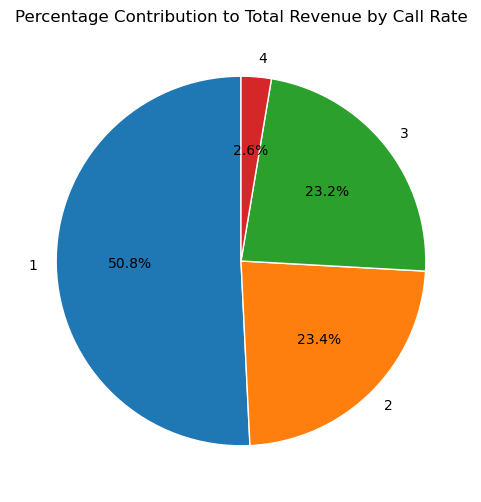

In [18]:
# Pie chart for percentage contribution to total revenue by call rate
# same as earlier but a different format to mget the percentages
plt.figure(figsize=(6, 6))
plt.pie(
    full_rates_df['total revenue euro'], 
    labels=full_rates_df['callrate'], 
    autopct='%1.1f%%', 
    startangle=90, 
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Percentage Contribution to Total Revenue by Call Rate', fontsize=12)
plt.show()

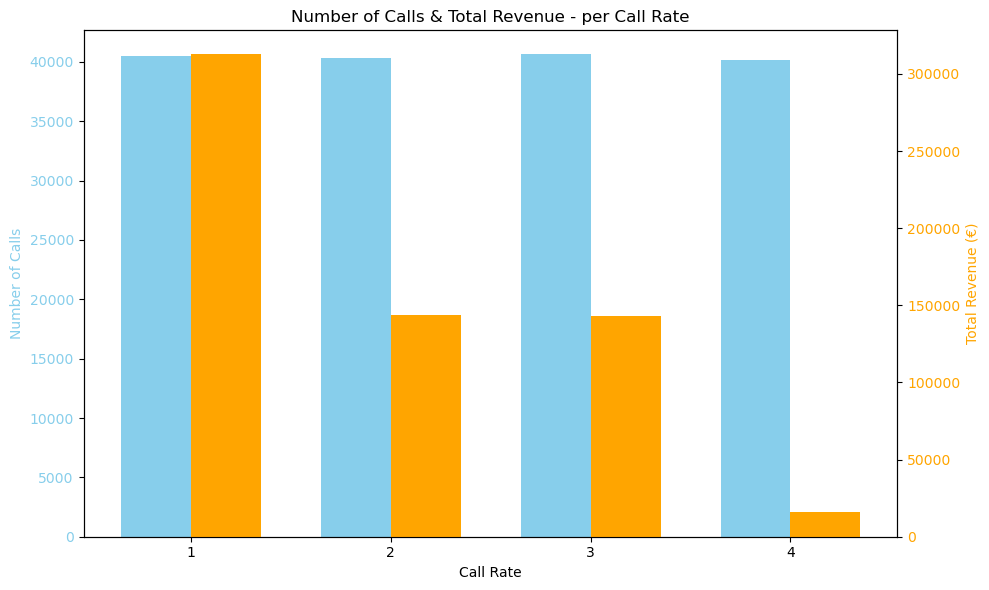

In [19]:
# plot for cal rates and revenue and num ber of calls
# we cna see the relatioshipt between the the elements more clearly and gain some insight into what is driving what
# define the three sets pf data we'll use,  we will use - revenue / call rate / number of calls
labels = full_rates_df['callrate'].astype(str)
num_calls = full_rates_df['num_of_calls']
revenue = full_rates_df['total revenue euro']

# define the bin width and label locations
x = np.arange(len(labels))
width = 0.35  

fig, ax1 = plt.subplots(figsize=(10,6))

# plot the data with labels
ax1.bar(x - width/2, num_calls, width, label='Number of Calls', color='skyblue')
ax1.set_xlabel('Call Rate')
ax1.set_ylabel('Number of Calls', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# Create a twin axis for revenue
ax2 = ax1.twinx()
ax2.bar(x + width/2, revenue, width, label='Total Revenue', color='orange')
ax2.set_ylabel('Total Revenue (€)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# define the title and la legend
plt.title('Number of Calls & Total Revenue - per Call Rate')
fig.tight_layout()
plt.show()

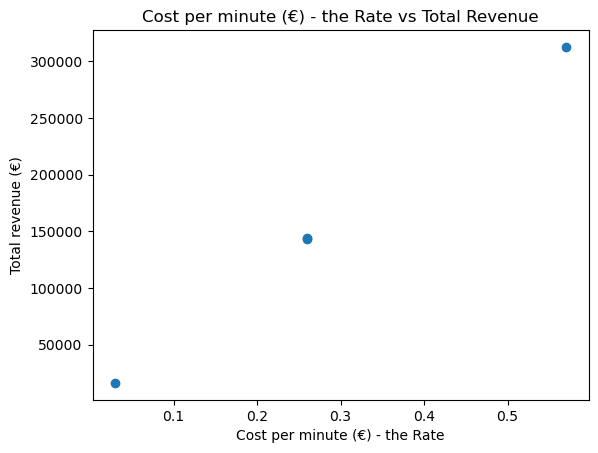

In [20]:
# relationship between cost per minute and total revenue is there a correlati between the two
# yes the higher the rate the hugher the revenue
plt.scatter(full_rates_df['costperminute'], full_rates_df['total revenue euro'])
plt.xlabel('Cost per minute (€) - the Rate')
plt.ylabel('Total revenue (€)')
plt.title('Cost per minute (€) - the Rate vs Total Revenue')
plt.show()

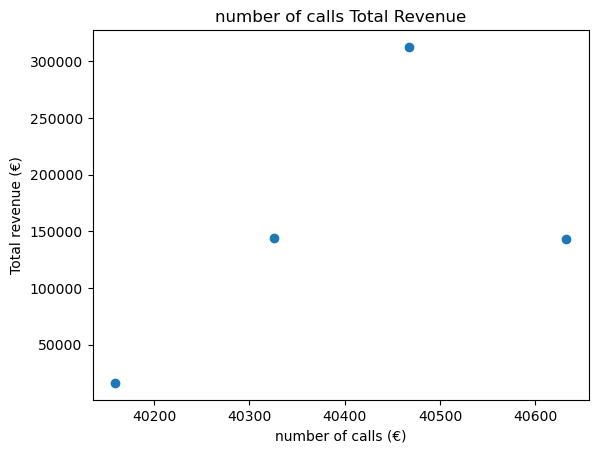

In [21]:
# relationship between number of calls and total revenue is there a correlation between the two
# yes the higher the rate the hugher the revenue
plt.scatter(full_rates_df['num_of_calls'], full_rates_df['total revenue euro'])
plt.xlabel('number of calls (€)')
plt.ylabel('Total revenue (€)')
plt.title('number of calls Total Revenue')
plt.show()

In [22]:
# identify a  correlation between the data 
# does a higher cost per minute corelate to a higher revenue?
full_rates_df[['costperminute', 'total revenue euro']].corr()


,costperminute,total revenue euro
costperminute,1.000000,0.999987
total revenue euro,0.999987,1.000000


In [23]:
full_rates_df[['num_of_calls', 'total revenue euro']].corr()

,num_of_calls,total revenue euro
num_of_calls,1.00000,0.57195
total revenue euro,0.57195,1.00000



### General Data Overview


**General Data Overview**

- There is an even spread of number of calls across all 4 rates, approx 40K in each
- revenue decreases as we go from rate 1 to 4, 1 being our max and 4 being our min
- Age Profile: Our youngest customer is approx 25, born in 2000 and our oldest customer is 75, born in 1950. This is a brad spread odages

**Revenue**
- Rates: our highest rate charge =  '.57' counts per min and our lowest rate charge = '0.03'. This is a relatively large spread.
- Average cost per minute is '.28' cents
- each call rate generates on average 153K euro, however standard deviation is big enough so there is a spread of data, a deviatin from our mean in our revenue data
- Rate to revenue contribution: rate 1 contributes 50.8% to revenue, just over half, whilst rate 4 contributes 2.6% to our revenue.
    - Rate 1 is our most profitable rate
    - Rate 1 ia also our International and Roaming rate.
- The minimum revenue for a phone = 0.14 euro, whereas the max revenue per phone = 483.59 euro. The average revenue per phone =125.14 euro

**Correlation / Relationships**
- There appears to be a strong linear relationship between call rate and revenue
    - there a strong positive correlation between the two, '.99' meaning the higher the call rate the higher the revenue 
- There is a relationship between cost per minute and Revenue, but is not a strong one
    - higher the cost per minute has an impact up to a point then the relationship breaks down
    - From the plots we can see number of calls doesn't necessarily lead to increased revenue
- There may be other factors in play driving revenue such as call duration, International and roaming which we would need to look into further. 


**Improvements / Next Steps**
- we don't have a customer ID number -  
    - need to add customer id and use as primary key to ensure uniqueness and more targetted analysis
    - customer could have more than one phone
    - only way to know how many individual customers there are woudl eb to dross ref
    - could have identical dates of birth many dob are these identical? 
    - from a business point of view if there are company phones and private phones we have no way to distinguish or potentailly upsell 
    - how many customers have more than one phone?
- International and Roaming
    - can be international call and on a roaming rate or not.
    - can be domestic and on a roaming rate or not
    - needs further analysis
- no analysis done around contract dates - area of future analysis
- no analysis around number of customer servcie calls per customer i.e. could be used as a measure or performance with less calls indictaing better performance, and percentage of customers who do and do not call customer service -area of future analysis

**Business Decisions**
 - consider getting rid of rate 4
 - Marketing - Consider focussing investments in getting customers for International and roaming rates as ths is our most profitable section
 - Consider raising the rate on the lowest rate, rate 4, as raising the rate has a direct relationship on revenue
 - Consider customer service analysis and time series analysis to measure performance and customer satisfaction.